Idea che mi è venuta:
conviene che i tempi li salviamo su un altro file tanto ci interessano relativamente, così è più semplice l'analisi.

##### Inclusioni

In [ ]:
# import sys
# print(sys.executable)

# basic
import numpy as np
import math as math
# import functions

# interpolation
from scipy.interpolate import interp1d
from scipy.optimize import fsolve

# inline plots
%matplotlib widget
import matplotlib.pyplot as plt
import mpld3

# Attiva l'interattività web (tanto non funziona)
mpld3.enable_notebook()
from matplotlib import cm
from matplotlib.colors import Normalize
from tqdm import tqdm
%matplotlib inline
from scipy.optimize import curve_fit

# nicer figures
import matplotlib as mpl
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False

# Prima deposizione - vetro 1, 28/04

### Identificazione regione ohmica

Minimo a T = 0.126 nm
Valore minimo R*T^2 = 0.4191071508531453


ValueError: cannot reshape array of size 0 into shape (0,newaxis)

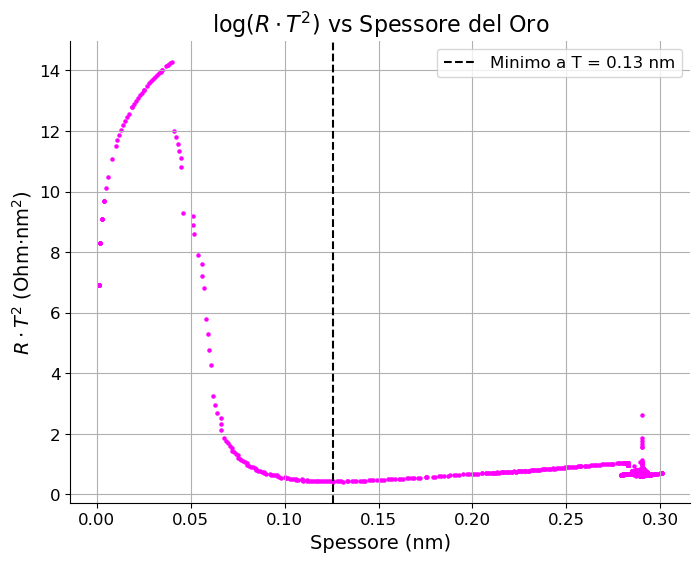

In [ ]:
#PRIMA DEPOSIZIONE
data = np.loadtxt('data/vetro_1_28_04.txt',usecols=(0,1),skiprows=1)
# estraiamo le colonne
R=data[:,0] #resistenza
T=data[:,1]*100 #thickness

#------------------CALCOLO RT^2 PER STIMARE REGIONE OHMICA------------------
mask= (T > 0) & (R > 0)
Tohm= T[mask]
Rohm= R[mask]
RT2 = Rohm * Tohm**2
logRT2 = np.log(RT2)
idx_min = np.argmin(RT2)
T_min1 = Tohm[idx_min]
logRT2_min = logRT2[idx_min]
print("Minimo a T =", T_min1, "nm")
print("Valore minimo R*T^2 =", logRT2_min)
plt.figure(figsize=(8,6))
plt.scatter(Tohm, logRT2, color='magenta', s=5)
plt.axvline(x=T_min1, color='black', linestyle='--', linewidth=1.5,label=fr'Minimo a T = {T_min1:.2f} nm')
plt.xlabel('Spessore (nm)')
plt.ylabel(r'$R \cdot T^2$ (Ohm$\cdot$nm$^2$)')
plt.title(r'log($R \cdot T^2$) vs Spessore del Oro')
plt.grid()
plt.legend()


differenzey = np.diff(RT2)
finestra=50
media_mobileRT2 = np.convolve(differenzey, np.ones(finestra)/finestra, mode='valid')
media_mobileTohm=np.convolve(Tohm[:-1], np.ones(finestra)/finestra, mode='valid')

# questi li si definisce a occhio, guardando RT^2 vs T
x_inf = 11
x_sup = 15

# Interpolazione
mask_zoom = (media_mobileTohm >= x_inf) & (media_mobileTohm <= x_sup) # limitiamoci a quello che visualizziamo
T_zoom = media_mobileTohm[mask_zoom]
Diff_zoom = media_mobileRT2[mask_zoom]

# Creiamo una funzione di interpolazione
f_interpolata = interp1d(T_zoom, Diff_zoom, kind='linear')

guess_iniziale = 13.0 
T_zero_esatto = fsolve(f_interpolata, guess_iniziale)[0]

# e quindi 
T_min1 = T_zero_esatto

print(f"T_min1 = {T_zero_esatto:.3f} nm")

# --- Visualizzazione (Opzionale ma consigliata) ---
plt.figure(figsize=(8,6))
plt.scatter(media_mobileTohm, media_mobileRT2, color='black', s=5, label='Media mobile')
plt.axhline(0, color='gray', linestyle='-', linewidth=1) # Linea dello zero
plt.axvline(T_zero_esatto, color='red', linestyle='--', label=f'Zero-crossing: {T_zero_esatto:.2f} nm')

plt.xlabel('Spessore (nm)')
plt.xlim(x_inf, x_sup)
plt.ylim(-100, 100)
plt.ylabel("differenze di R*T^2")  
plt.title(r'$\Delta$($R \cdot T^2$) vs T')
plt.grid()
plt.legend()
plt.show()
#------------------------FINE CALCOLO RT^2------------------


### Parametri fit di tunneling

In [ ]:
# Una cosa importante è selezionare in automatico l'inizio
# della tegione...
# Tipo trovando il primo indice per cui R è minore di 1000000000

#------------------ FIT TUNNELING ------------------
mask = (T > 4.2) & (T < 6) & (R > 0)
T_tun = T[mask]
R_tun = R[mask]
# --- modello tunneling ---
# R = R0 * exp(-alpha * d)
def tunnel_model(d, R0, alpha):
    return R0 * np.exp(-alpha * d)
# --- fit in log-space ---
# log R = log R0 - alpha*d
def log_tunnel_model(d, logR0, alpha):
    return logR0 - alpha * d
p0 = [np.log(np.max(R_tun)), 1.0]
params, cov = curve_fit(
    log_tunnel_model,
    T_tun,
    np.log(R_tun),
    p0=p0,
    maxfev=10000
)
logR0_fit1, alpha_fit1 = params
R0_fit1 = np.exp(logR0_fit1)
errors = np.sqrt(np.diag(cov))
err_logR0, err_alpha1 = errors
# --- curva fit ---
T_curvetun = np.linspace(4.2, 6, 500)
R_curvetun = tunnel_model(T_curvetun, R0_fit1, alpha_fit1)
#-------------------FINE FIT TUNNELING------------------


### Identificazione regione percolativa

/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1290: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1290: RuntimeWarning: invalid value encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1291: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1291: RuntimeWarning: invalid value encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1292: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1292: RuntimeWarning: invalid value encountered in divide
  c = dx1 / (dx2 * (dx1 +

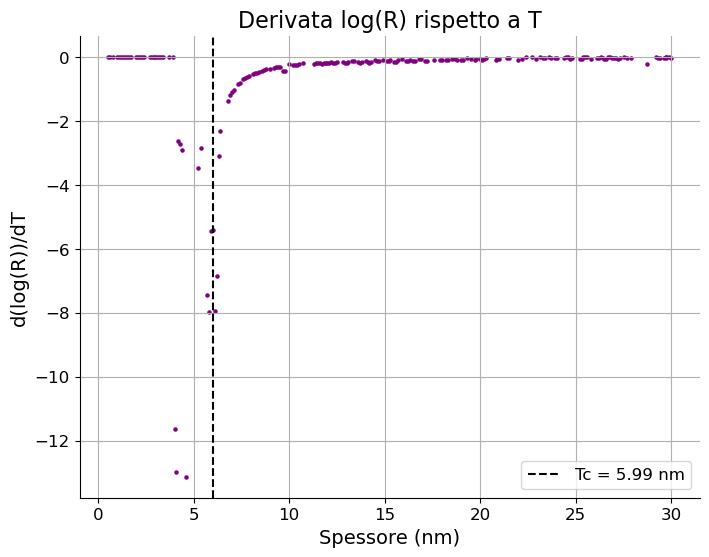

In [5]:

#------------------ FIT PERCOLAZIONE ------------------
# --- filtro dati ---
mask = (T > 0) & (R > 0)

# scelgo regione vicino alla percolazione
mask &= (T > 6) & (T < T_min1)
T_fit = T[mask]
R_fit = R[mask]
# --- modello logaritmico ---
# R = A * (d - dc)^(-t)
# log(R) = log(A) - t * log(d - dc)
def log_model(T, logA, dc, t):
    return logA - t * np.log(T - dc)
# --- guess iniziali ---
logA0 = np.log(1e4)
dc0 = 4.0
t0 = 1.3
p0 = [logA0, dc0, t0]
# --- bounds ---
bounds = (
    [-np.inf, 0, 0.1],
    [np.inf, np.min(T_fit)*0.999, 5.0]
)
# --- fit ---
params, cov = curve_fit(
    log_model,
    T_fit,
    np.log(R_fit),
    p0=p0,
    bounds=bounds,
    maxfev=20000
)
logA_fit1, Tc_fit1, t_fit1 = params
A_fit1 = np.exp(logA_fit1)
# errori sui parametri
errors = np.sqrt(np.diag(cov))
err_logA1, err_Tc1, err_t1 = errors
# --- curva fit ---
T_curve = np.linspace(Tc_fit1 + 0.01, np.max(T_fit), 1000)
R_curve = A_fit1 * (T_curve - Tc_fit1)**(-t_fit1)
#------------------FINE FIT PERCOLAZIONE------------------


#------------------- CALCOLO DERIVATA logRvsT------------------
logR = np.log(R)
dlogR_dT = np.gradient(logR, T)
plt.figure(figsize=(8,6))
plt.scatter(T, dlogR_dT, color='purple',s=5)
plt.axvline(x=Tc_fit1, color='black', linestyle='--', linewidth=1.5,label=fr'Tc = {Tc_fit1:.2f} nm')
plt.xlabel('Spessore (nm)')
plt.ylabel('d(log(R))/dT')
plt.title('Derivata log(R) rispetto a T')
plt.legend()
plt.grid()
plt.show()
#------------------ FINE CALCOLO DERIVATA ------------------


### Curva percolativa

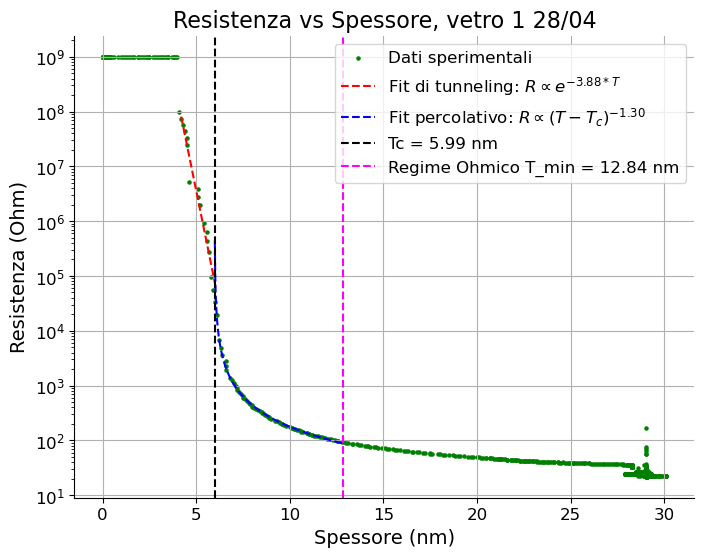

Parametri del fit di tunneling: R0*exp(-alpha*d)
R0 = 9.7691e+14 Ohm
alpha = 3.8831 1/nm ± 0.2423 1/nm
Parametri del fit percolativo: R = A * (T - Tc)^(-t)
A  = 1.0872e+03
Tc = 5.9857 nm ± 0.0073 nm
t  = 1.3048 ± 0.0130


In [6]:
# Grafico dati & teoria curva percolativa
plt.figure(figsize=(8,6))
plt.scatter(T, R, color='green', label='Dati sperimentali', s=5)
plt.plot(T_curvetun,R_curvetun,color='red',label=fr'Fit di tunneling: $R \propto e^{{{-alpha_fit1:.2f}*T}}$', linestyle='--')
plt.plot(T_curve, R_curve, color='blue',label=fr'Fit percolativo: $R \propto (T-T_c)^{{{-t_fit1:.2f}}}$',linestyle='--')
plt.axvline(x=Tc_fit1, color='black', linestyle='--', linewidth=1.5,label=fr'Tc = {Tc_fit1:.2f} nm')
plt.axvline(x=T_min1, color='magenta', linestyle='--', linewidth=1.5,label=fr'Regime Ohmico T_min = {T_min1:.2f} nm')
plt.yscale('log')
plt.xlabel('Spessore (nm)')
plt.ylabel('Resistenza (Ohm)')
plt.title('Resistenza vs Spessore, vetro 1 28/04')
plt.legend()
plt.grid()
plt.show()

#------------------------ STAMPA PARAMETRI FIT ------------------
print("Parametri del fit di tunneling: R0*exp(-alpha*d)")
print(f"R0 = {R0_fit1:.4e} Ohm")
print(f"alpha = {alpha_fit1:.4f} 1/nm ± {err_alpha1:.4f} 1/nm")

print("Parametri del fit percolativo: R = A * (T - Tc)^(-t)")
print(f"A  = {A_fit1:.4e}")
print(f"Tc = {Tc_fit1:.4f} nm ± {err_Tc1:.4f} nm")
print(f"t  = {t_fit1:.4f} ± {err_t1:.4f}")


### Transizione cristallina

#### Transizione nanocristallina-bulk

X^2_tot = 2.24; T_crit = 20.7
Fit parameters for bulk conduction (deposition 1):
A_0 = 2.1379e+03 Ω·nm
A_1 = -4.0084e+04 Ω·nm^2
A_3 = 6.8552e+06 Ω·nm^4 


A_0_2 = 1.1065e+03 Ω·nm
A_1_2 = -5.0675e+03 Ω·nm^2
A_3_2 = 1.0316e+06 Ω·nm^4 




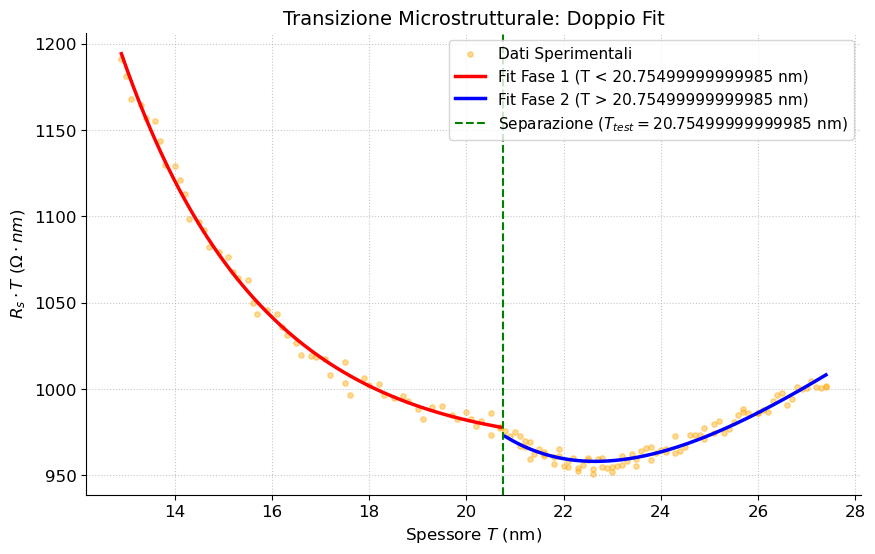

In [7]:
# Transizione nanocristallino-bulk

# Costanti fisiche (unità SI)
h = 6.62607015E-34 # J*s
e = 1.602176634E-19 # C
n = 5.9E28 # m^(-3)
k_f = 1.2E10 # m^(-1)
rho_0 = 2.25E-8 # Ω*m

# Parametri
lambda_0 = (h*k_f)/(2*math.pi*n*(e**2)*rho_0) # m


# rho_inf
# selezione dati
data = np.loadtxt('data/vetro_1_28_04.txt',usecols=(0,1),skiprows=1)
# estraiamo le colonne
R=data[:,0] #resistenza
T=data[:,1]*100 #thickness
T_max1 = np.max(T)
mask_C = (T > T_min1) & (R>0) & (T<=27.5)
T_ac1 = T[mask_C]
R_ac1 = R[mask_C]
RT1 = R_ac1*T_ac1
def fit_function(t, A_0, A_1, A_3):
    return A_0 + (A_1 / t) + (A_3 / (t**3))

# Bisognerebbe fare i minimi quadrati spostando man mano il punto di separazione

T_test = 20 # spessore test, nm
T_crit = 20
X2_tot = 50
A0_ncr = np.inf
A1_ncr = np.inf
A3_ncr = np.inf
A0_cr = np.inf
A1_cr = np.inf
A3_cr = np.inf
cov = 0

# Mo' bisognerebbe fare un bel ciclo while/for per spannare tutti i valori intorno...

dT = 0.005
while(T_test < 20.75):
    mask_ncr = mask_C & (T < T_test) # nano crystals
    mask_cr = mask_C & (T>T_test) # crystals
    T_ncr1 = T[mask_ncr]
    T_cr1 = T[mask_cr]
    RT_ncr1 = R[mask_ncr]*T_ncr1
    RT_cr1 = R[mask_cr]*T_cr1

    # Facciamo i due fit separatamente, vediamo per che valore di T_test c'è l'accordo migliore

    # Calcolo dei parametri:
    par_ncr1, cov_ncr1 = curve_fit(fit_function, T_ncr1, RT_ncr1)
    A0_ncr1, A1_ncr1, A3_ncr1 = par_ncr1
    par_cr1, cov_cr1 = curve_fit(fit_function, T_cr1, RT_cr1)
    A0_cr1, A1_cr1, A3_cr1 = par_cr1

    # Calcolo del X^2 = sum((x-exp)^2/exp)

    # Valori attesi con i due fit: 
    RTexp_ncr1 = fit_function(T_ncr1, A0_ncr1, A1_ncr1, A3_ncr1)
    RTexp_cr1 = fit_function(T_cr1, A0_cr1, A1_cr1, A3_cr1)

    # chi2
    X2_ncr1 = np.sum((RT_ncr1-RTexp_ncr1)**2/RTexp_ncr1)
    X2_cr1 = np.sum((RT_cr1-RTexp_cr1)**2/RTexp_cr1)
    X2_tot_new = X2_cr1 + X2_ncr1
    if(X2_tot_new < X2_tot): 
        X2_tot = X2_tot_new
        T_crit = T_test
        A0_ncr = A0_ncr1
        A1_ncr = A1_ncr1
        A3_ncr = A3_ncr1
        A0_cr = A0_cr1
        A1_cr = A1_cr1
        A3_cr = A3_cr1
        cov = cov_cr1
    T_test += dT

print(f"X^2_tot = {X2_tot:.3}; T_crit = {T_crit:.4}")

print(f"Fit parameters for bulk conduction (deposition 1):")
print(f"A_0 = {A0_cr:.4e} Ω·nm")
print(f"A_1 = {A1_cr:.4e} Ω·nm^2")
print(f"A_3 = {A3_cr:.4e} Ω·nm^4 \n\n")
print(f"A_0_2 = {A0_ncr:.4e} Ω·nm")
print(f"A_1_2 = {A1_ncr:.4e} Ω·nm^2")
print(f"A_3_2 = {A3_ncr:.4e} Ω·nm^4 \n\n")

# plottiamo 
T_ncr1_smooth = np.linspace(np.min(T_ncr1), np.max(T_ncr1), 200)
T_cr1_smooth = np.linspace(np.min(T_cr1), np.max(T_cr1), 200)

RT_ncr1_smooth = fit_function(T_ncr1_smooth, *par_ncr1)
RT_cr1_smooth = fit_function(T_cr1_smooth, *par_cr1)

plt.figure(figsize=(10, 6))

# Plot dei dati sperimentali interi
plt.scatter(T_ac1, RT1, color='orange', s=15, alpha=0.4, label='Dati Sperimentali')

# Plot del Fit 1 (nanocrystals)
plt.plot(T_ncr1_smooth, RT_ncr1_smooth, color='red', linewidth=2.5, 
         label=f'Fit Fase 1 (T < {T_test} nm)')

# Plot del Fit 2 (bulk)
plt.plot(T_cr1_smooth, RT_cr1_smooth, color='blue', linewidth=2.5, 
         label=f'Fit Fase 2 (T > {T_test} nm)')

# Linea verticale per indicare T_test
plt.axvline(x=T_test, color='green', linestyle='--', linewidth=1.5, 
            label=f'Separazione ($T_{{test}} = {T_test}$ nm)')

plt.xlabel('Spessore $T$ (nm)', fontsize=12)
plt.ylabel('$R_s \cdot T$ ($\Omega \cdot nm$)', fontsize=12)
plt.title('Transizione Microstrutturale: Doppio Fit', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.savefig('fig/vetro_1_28_04/nanocrystalline_bulk_1.pdf', format='pdf', bbox_inches='tight')

plt.show()


#### Grain size

rho_inf = 452.479 ± 5.0 Ω*nm = 0.452 ± 0.0 microΩ*m
X2 = 75.2
Grain size D_g = 1.94 ± 0.02 nm


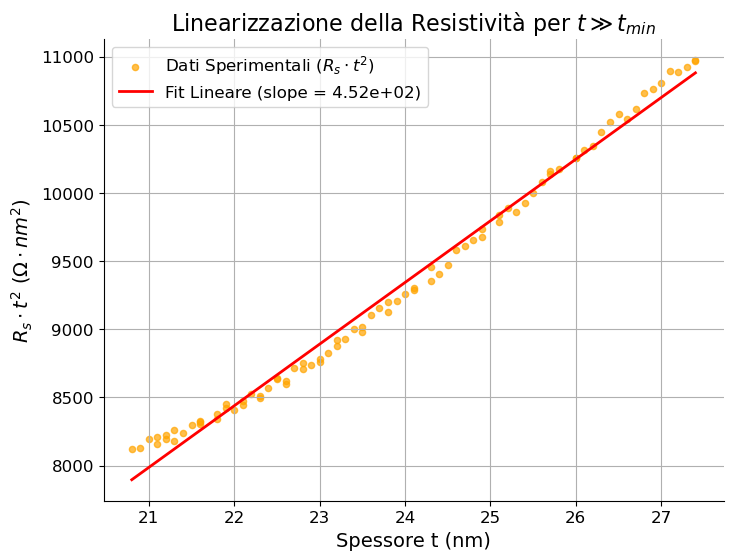

In [8]:
# Regione metallica continua: grain size
mask_inf = mask_C & (T > T_crit)
T_inf1 = T[mask_inf]
R_inf1 = R[mask_inf]

# R VA MOLTIPLICATO PER (LARGHEZZA DELLA MASCHERA/LUNGHEZZA DELLA MASCHERA)
W = 2
L = 5 # è solo un'ipotesi, in mm
s_factor = W / L
R_inf1 = R_inf1 * s_factor
RT2 = R_inf1 * (T_inf1**2)

def retta(x, m, q):
    return m * x + q

# fit
popt, pcov = curve_fit(retta, T_inf1, RT2)

# fit data
rho_inf = popt[0]
q = popt[1]

# errore rho_inf dal fit
errori = np.sqrt(np.diag(pcov))
err_rho_inf = errori[0] # sigma_rho_inf in Ω·nm

# chi2 (come tutti gli altri andrà ricalcolato con gli errori...)
X2 = np.sum((rho_inf*T_inf1 + q - RT2)**2/(rho_inf*T_inf1 + q))

print(f"rho_inf = {rho_inf:.3f} ± {err_rho_inf:.1f} Ω*nm = {(rho_inf*0.001):.3f} ± {(err_rho_inf*0.001):.1f} microΩ*m")
print(f"X2 = {X2:.3}")

# Grain size
# Convertiamo in metri
rho_inf_m = rho_inf * 1e-9
err_rho_inf_m = err_rho_inf * 1e-9

# D_g
D_g_m = (rho_0 * lambda_0) / (rho_inf_m - rho_0) # m

# Propagazione dell'errore su D_g_m
err_Dg_m = (rho_0 * lambda_0 / ((rho_inf_m - rho_0)**2)) * err_rho_inf_m

# in nanometri
D_g_nm = D_g_m * 1e9 # nm
err_Dg_nm = err_Dg_m * 1e9 # nm

print(f"Grain size D_g = {D_g_nm:.2f} ± {err_Dg_nm:.2f} nm")


# plotting - rho_inf
plt.figure(figsize=(8,6))
plt.scatter(T_inf1, RT2, color='orange', label='Dati Sperimentali ($R_s \cdot t^2$)', s=20, alpha=0.7)

# Calcoliamo i punti della retta fittata
Y_fit = (rho_inf * T_inf1) + q
plt.plot(T_inf1, Y_fit, color='red', linewidth=2, label=f'Fit Lineare (slope = {rho_inf:.2e})')

plt.xlabel('Spessore t (nm)')
plt.ylabel('$R_s \cdot t^2$ ($\Omega \cdot nm^2$)')
plt.title('Linearizzazione della Resistività per $t \gg t_{min}$')
plt.legend()
plt.grid(True)
plt.savefig('fig/vetro_1_28_04/rho_inf_1.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Il X2 viene gigante, ma forse per capire esattamente da quando ha senso fare il fit 
# bisogna stimare tutti gli errori e calcolarlo perbene...

# Seconda deposizione - vetro 2, 28/04

### Identificazione regione ohmica

Minimo a T = 16.7 nm
Valore minimo R*T^2 = 10.010466248733337
Il valore esatto in cui la differenza passa per lo 0 (T_min) è: 16.991 nm


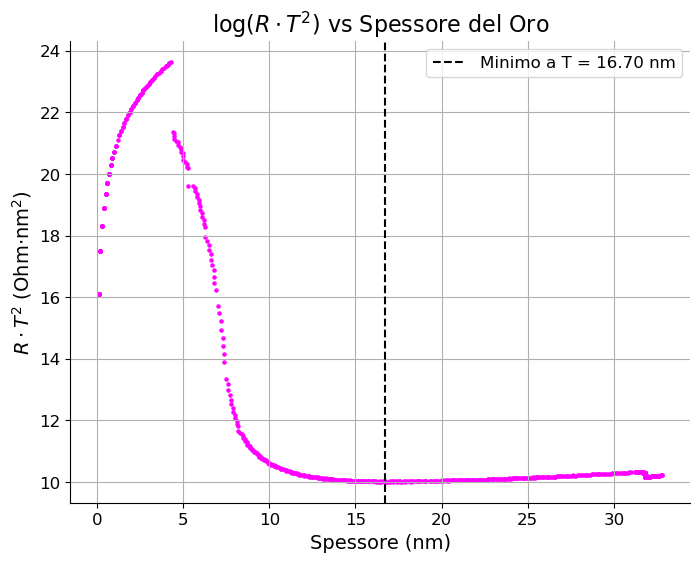

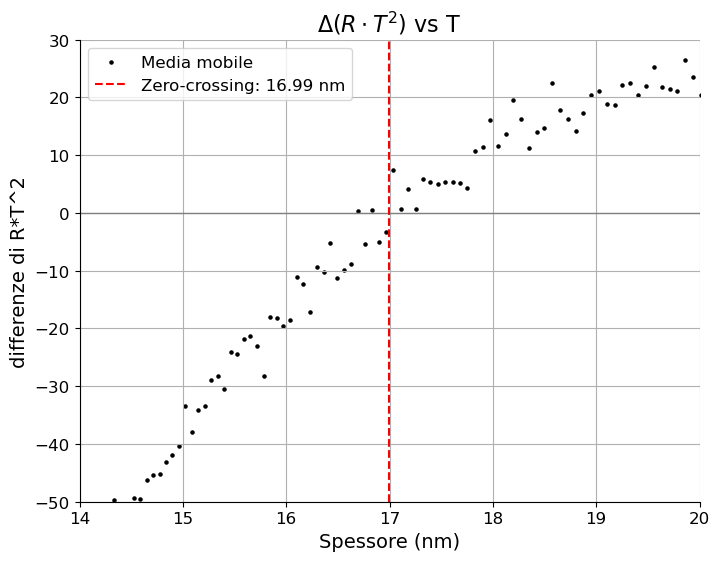

In [9]:
#SECONDA DEPOSIZIONE
data = np.loadtxt('data/vetro_2_28_04.txt',usecols=(0,1),skiprows=1)
dato=np.loadtxt('data/vetro_2_28_04.txt',usecols=(4),skiprows=1)
rates=dato*0.1
#estraiamo le colonne
R=data[:,0] #resistenza
T=data[:,1]*100 #thickness

#------------------CALCOLO RT^2 PER STIMARE REGIONE OHMICA------------------
mask= (T > 0) & (R > 0)
Tohm= T[mask]
Rohm= R[mask]
RT2 = Rohm * Tohm**2
logRT2 = np.log(RT2)
idx_min = np.argmin(RT2)
T_min2 = Tohm[idx_min]
logRT2_min = logRT2[idx_min]
print("Minimo a T =", T_min2, "nm")
print("Valore minimo R*T^2 =", logRT2_min)
plt.figure(figsize=(8,6))
plt.scatter(Tohm, logRT2, color='magenta', s=5)
plt.axvline(x=T_min2, color='black', linestyle='--', linewidth=1.5,label=fr'Minimo a T = {T_min2:.2f} nm')
plt.xlabel('Spessore (nm)')
plt.ylabel(r'$R \cdot T^2$ (Ohm$\cdot$nm$^2$)')
plt.title(r'log($R \cdot T^2$) vs Spessore del Oro')
plt.grid()
plt.legend()


differenzey = np.diff(RT2)
finestra=50
media_mobileRT2 = np.convolve(differenzey, np.ones(finestra)/finestra, mode='valid')
media_mobileTohm=np.convolve(Tohm[:-1], np.ones(finestra)/finestra, mode='valid')

x_inf = 14
x_sup = 20

# Interpolazione
mask_zoom = (media_mobileTohm >= x_inf) & (media_mobileTohm <= x_sup) # limitiamoci a quello che visualizziamo
T_zoom = media_mobileTohm[mask_zoom]
Diff_zoom = media_mobileRT2[mask_zoom]

# Creiamo una funzione di interpolazione
f_interpolata = interp1d(T_zoom, Diff_zoom, kind='linear')

guess_iniziale = 17.0 
T_zero_esatto = fsolve(f_interpolata, guess_iniziale)[0]

# e quindi 
T_min2 = T_zero_esatto

print(f"Il valore esatto in cui la differenza passa per lo 0 (T_min) è: {T_zero_esatto:.3f} nm")

# --- Visualizzazione (Opzionale ma consigliata) ---
plt.figure(figsize=(8,6))
plt.scatter(media_mobileTohm, media_mobileRT2, color='black', s=5, label='Media mobile')
plt.axhline(0, color='gray', linestyle='-', linewidth=1) # Linea dello zero
plt.axvline(T_zero_esatto, color='red', linestyle='--', label=f'Zero-crossing: {T_zero_esatto:.2f} nm')

plt.xlabel('Spessore (nm)')
plt.xlim(14, 20)
plt.ylim(-50, 30)
plt.ylabel("differenze di R*T^2")  
plt.title(r'$\Delta$($R \cdot T^2$) vs T')
plt.grid()
plt.legend()
plt.show()
#------------------------FINE CALCOLO RT^2------------------


### Identificazione regione di tunneling

In [10]:
#------------------- FIT TUNNELING ------------------
mask = (T > 4.7) & (T < 7.3) & (R > 0)
T_tun = T[mask]
R_tun = R[mask]
# --- modello tunneling ---
# R = R0 * exp(-alpha * d)
def tunnel_model(d, R0, alpha):
    return R0 * np.exp(-alpha * d)

# --- fit in log-space ---
# log R = log R0 - alpha*d
def log_tunnel_model(d, logR0, alpha):
    return logR0 - alpha * d
p0 = [np.log(np.max(R_tun)), 1.0]
params, cov = curve_fit(
    log_tunnel_model,
    T_tun,
    np.log(R_tun),
    p0=p0,
    maxfev=10000
)
logR0_fit, alpha_fit2 = params
R0_fit2 = np.exp(logR0_fit)
# --- curva fit ---
T_curvetun = np.linspace(4.7, 7.3, 500)
R_curvetun = tunnel_model(T_curvetun, R0_fit2, alpha_fit2)
#errori sui parametri di tunneling
errors = np.sqrt(np.diag(cov))
err_logR0, err_alpha2 = errors
#-------------------FINE FIT TUNNELING------------------


### Identificazione regione percolativa

In [11]:
#------------------ FIT PERCOLAZIONE ------------------
mask = (T > 0) & (R > 0)

# scelgo regione vicino alla percolazione
mask &= (T > 7.32) & (T < T_min2)
T_fit = T[mask]
R_fit = R[mask]
# --- modello logaritmico ---
# R = A * (d - dc)^(-t)
# log(R) = log(A) - t * log(d - dc)
def log_model(T, logA, dc, t):
    return logA - t * np.log(T - dc)
# --- guess iniziali ---
logA0 = np.log(1e4)
dc0 = 7.0
t0 = 1.3
p0 = [logA0, dc0, t0]
# --- bounds ---
bounds = (
    [-np.inf, 0, 0.1],
    [np.inf, np.min(T_fit)*0.999, 5.0]
)
# --- fit ---
params, cov = curve_fit(
    log_model,
    T_fit,
    np.log(R_fit),
    p0=p0,
    bounds=bounds,
    maxfev=20000
)
logA_fit, Tc_fit2, t_fit2 = params
A_fit2 = np.exp(logA_fit)
# --- curva fit ---
T_curve = np.linspace(Tc_fit2 + 0.01, np.max(T_fit), 1000)
R_curve = A_fit2 * (T_curve - Tc_fit2)**(-t_fit2)
# errori sui parametri di percolazione
errors = np.sqrt(np.diag(cov))
err_logA, err_Tc2, err_t2 = errors
#------------------FINE FIT PERCOLAZIONE------------------


### Plotting

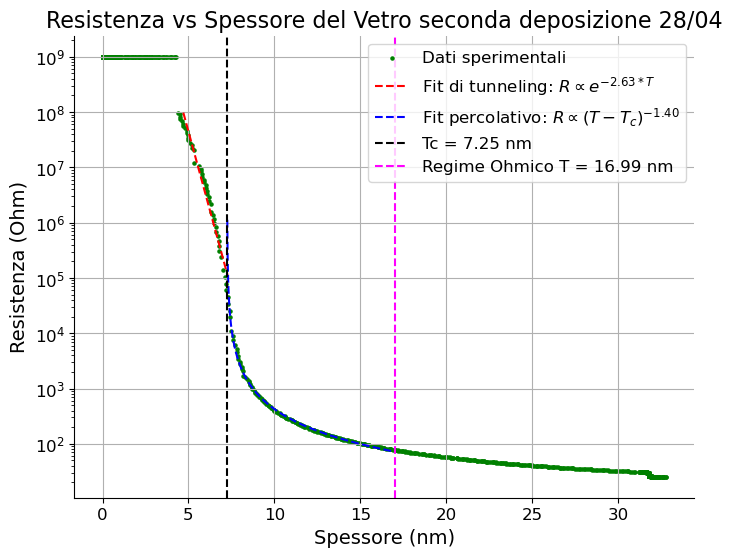

/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1290: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1290: RuntimeWarning: invalid value encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1291: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1291: RuntimeWarning: invalid value encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1292: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1292: RuntimeWarning: invalid value encountered in divide
  c = dx1 / (dx2 * (dx1 +

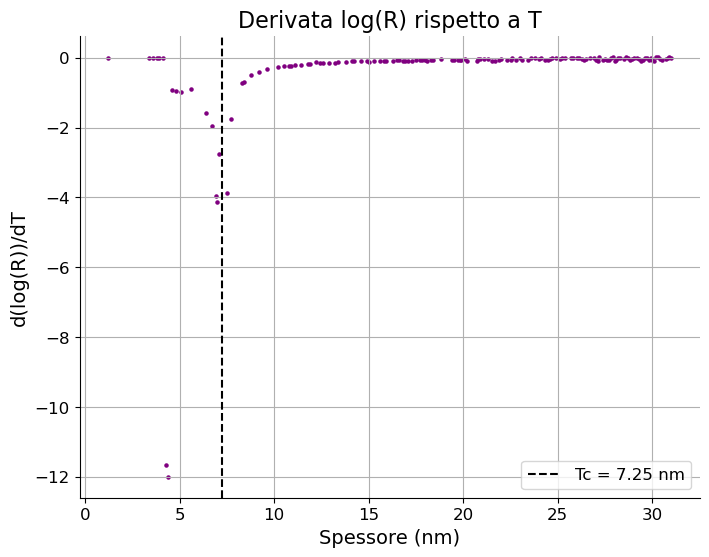

Parametri del fit di tunneling: R0*exp(-alpha*d)
R0 = 2.2750e+13 Ohm
alpha = 2.6299 1/nm ± 0.0738 1/nm
Parametri del fit percolativo: R = A * (T - Tc)^(-t)
A  = 1.7583e+03
Tc = 7.2484 nm ± 0.0062 nm
t  = 1.4029 ± 0.0086


In [12]:
#creo un grafico con dati e fit
plt.figure(figsize=(8,6))
plt.scatter(T, R, color='green', label='Dati sperimentali', s=5)
plt.plot(T_curvetun, R_curvetun, color='red', label=fr'Fit di tunneling: $R \propto e^{{{-alpha_fit2:.2f}*T}}$', linestyle='--')
plt.plot(T_curve, R_curve, color='blue',label=fr'Fit percolativo: $R \propto (T-T_c)^{{{-t_fit2:.2f}}}$',linestyle='--')

plt.axvline(x=Tc_fit2, color='black', linestyle='--', linewidth=1.5,label=fr'Tc = {Tc_fit2:.2f} nm')
plt.axvline(x=T_min2, color='magenta', linestyle='--', linewidth=1.5,label=fr'Regime Ohmico T = {T_min2:.2f} nm')
plt.yscale('log')
plt.xlabel('Spessore (nm)')
plt.ylabel('Resistenza (Ohm)')
plt.title('Resistenza vs Spessore del Vetro seconda deposizione 28/04')
plt.legend()
plt.grid()
plt.show()


#------------------- CALCOLO DERIVATA logRvsT------------------
logR = np.log(R)
dlogR_dT = np.gradient(logR, T)
plt.figure(figsize=(8,6))
plt.scatter(T, dlogR_dT, color='purple',s=5)
plt.axvline(x=Tc_fit2, color='black', linestyle='--', linewidth=1.5,label=fr'Tc = {Tc_fit2:.2f} nm')
plt.xlabel('Spessore (nm)')
plt.ylabel('d(log(R))/dT')
plt.title('Derivata log(R) rispetto a T')
plt.legend()
plt.grid()
plt.show()
#------------------ FINE CALCOLO DERIVATA ------------------




#------------------------ STAMPA PARAMETRI FIT ------------------
print("Parametri del fit di tunneling: R0*exp(-alpha*d)")
print(f"R0 = {R0_fit2:.4e} Ohm")
print(f"alpha = {alpha_fit2:.4f} 1/nm ± {err_alpha2:.4f} 1/nm")

print("Parametri del fit percolativo: R = A * (T - Tc)^(-t)")
print(f"A  = {A_fit2:.4e}")
print(f"Tc = {Tc_fit2:.4f} nm ± {err_Tc2:.4f} nm")
print(f"t  = {t_fit2:.4f} ± {err_t2:.4f}")



### Transizione cristallina

#### Controllo transizione di fase

/var/folders/pv/g7twvrbn3wl5dfj28y3cp65h0000gp/T/ipykernel_2275/709731809.py:65: OptimizeWarning: Covariance of the parameters could not be estimated
  par_cr1, cov_cr1 = curve_fit(fit_function, T_cr1, RT_cr1)


X^2_tot = 3.68e+03; T_crit = 24.0
Fit parameters for bulk conduction (deposition 1):
A_0 = 1.3914e+03 Ω·nm
A_1 = -1.9352e+04 Ω·nm^2
A_2 = 6.1807e+06 Ω·nm^4 


A_0_2 = 6.4925e+02 Ω·nm
A_1_2 = 6.7845e+03 Ω·nm^2
A_3_2 = 1.3096e+06 Ω·nm^4 




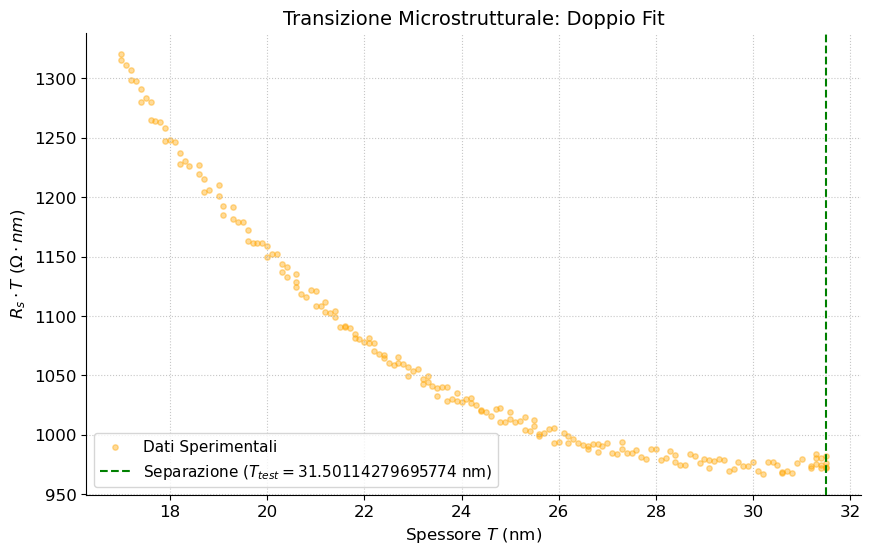

In [22]:
# Transizione nanocristallino-bulk

# Costanti fisiche (unità SI)
h = 6.62607015E-34 # J*s
e = 1.602176634E-19 # C
n = 5.9E28 # m^(-3)
k_f = 1.2E10 # m^(-1)
rho_0 = 2.25E-8 # Ω*m

# Parametri
lambda_0 = (h*k_f)/(2*math.pi*n*(e**2)*rho_0) # m


# rho_inf
# selezione dati
data = np.loadtxt('data/vetro_2_28_04.txt',usecols=(0,1),skiprows=1)
# estraiamo le colonne
R=data[:,0] #resistenza
T=data[:,1]*100 #thickness
T_max1 = np.max(T)
mask_C = (T > T_min2) & (R>0) & (T<=31.5)
T_ac1 = T[mask_C]
R_ac1 = R[mask_C]
RT1 = R_ac1*T_ac1
def fit_function(t, A_0, A_1, A_3):
    return A_0 + (A_1 / t) + (A_3 / (t**3))

# Bisognerebbe fare i minimi quadrati spostando man mano il punto di separazione

T_test = T_min2 # spessore test, nm
X2_tot = np.inf # MEGLIO INFINITO: così il primo giro utile vince sicuramente

# Inizializziamo a zero per sicurezza
T_crit = T_test
A0_ncr = A1_ncr = A3_ncr = 0
A0_cr = A1_cr = A3_cr = 0
cov = 0.0

# Mo' bisognerebbe fare un bel ciclo while/for per spannare tutti i valori intorno...
dT = 0.005

while T_test < 31.5:
    mask_ncr = mask_C & (T < T_test) # nano crystals
    mask_cr = mask_C & (T >= T_test) # crystals
    
    T_ncr1 = T[mask_ncr]
    T_cr1 = T[mask_cr]
    
    # -------------------------------------------------------------
    # LA RETE DI SICUREZZA:
    # curve_fit ha 3 parametri, servono almeno 4 punti per regione.
    # Se ce ne sono meno, saltiamo questo giro per evitare errori!
    # -------------------------------------------------------------
    if len(T_ncr1) < 4 or len(T_cr1) < 4:
        T_test += dT
        continue

    RT_ncr1 = R[mask_ncr]*T_ncr1
    RT_cr1 = R[mask_cr]*T_cr1

    # Facciamo i due fit separatamente
    par_ncr1, cov_ncr1 = curve_fit(fit_function, T_ncr1, RT_ncr1)
    A0_ncr1, A1_ncr1, A3_ncr1 = par_ncr1
    
    par_cr1, cov_cr1 = curve_fit(fit_function, T_cr1, RT_cr1)
    A0_cr1, A1_cr1, A3_cr1 = par_cr1

    # Valori attesi
    RTexp_ncr1 = fit_function(T_ncr1, A0_ncr1, A1_ncr1, A3_ncr1)
    RTexp_cr1 = fit_function(T_cr1, A0_cr1, A1_cr1, A3_cr1)

    # Calcolo Somma dei Residui (meglio senza dividere per RTexp per dati continui)
    X2_ncr1 = np.sum((RT_ncr1 - RTexp_ncr1)**2)
    X2_cr1 = np.sum((RT_cr1 - RTexp_cr1)**2)
    
    X2_tot_new = X2_cr1 + X2_ncr1
    
    # Aggiornamento Record
    if X2_tot_new < X2_tot: 
        X2_tot = X2_tot_new
        T_crit = T_test
        A0_ncr, A1_ncr, A3_ncr = A0_ncr1, A1_ncr1, A3_ncr1
        A0_cr, A1_cr, A3_cr = A0_cr1, A1_cr1, A3_cr1
        cov = cov_cr1
        
    T_test += dT

print(f"X^2_tot = {X2_tot:.3}; T_crit = {T_crit:.4}")

print(f"Fit parameters for bulk conduction (deposition 1):")
print(f"A_0 = {A0_cr:.4e} Ω·nm")
print(f"A_1 = {A1_cr:.4e} Ω·nm^2")
print(f"A_2 = {A3_cr:.4e} Ω·nm^4 \n\n")
print(f"A_0_2 = {A0_ncr:.4e} Ω·nm")
print(f"A_1_2 = {A1_ncr:.4e} Ω·nm^2")
print(f"A_3_2 = {A3_ncr:.4e} Ω·nm^4 \n\n")

# plottiamo 
T_ncr1_smooth = np.linspace(np.min(T_ncr1), np.max(T_ncr1), 200)
T_cr1_smooth = np.linspace(np.min(T_cr1), np.max(T_cr1), 200)

RT_ncr1_smooth = fit_function(T_ncr1_smooth, *par_ncr1)
RT_cr1_smooth = fit_function(T_cr1_smooth, *par_cr1)

plt.figure(figsize=(10, 6))

# Plot dei dati sperimentali interi
plt.scatter(T_ac1, RT1, color='orange', s=15, alpha=0.4, label='Dati Sperimentali')

# Plot del Fit 1 (nanocrystals)
# plt.plot(T_ncr1_smooth, RT_ncr1_smooth, color='red', linewidth=2.5, 
         # label=f'Fit Fase 1 (T < {T_test} nm)')

# Plot del Fit 2 (bulk)
# plt.plot(T_cr1_smooth, RT_cr1_smooth, color='blue', linewidth=2.5, 
         # label=f'Fit Fase 2 (T > {T_test} nm)')

# Linea verticale per indicare T_test
plt.axvline(x=T_test, color='green', linestyle='--', linewidth=1.5, 
            label=f'Separazione ($T_{{test}} = {T_test}$ nm)')

plt.xlabel('Spessore $T$ (nm)', fontsize=12)
plt.ylabel('$R_s \cdot T$ ($\Omega \cdot nm$)', fontsize=12)
plt.title('Transizione Microstrutturale: Doppio Fit', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)

plt.show()

#### Calcolo grain size

rho_inf = 337.496 ± 3.4 Ω*nm = 0.337 ± 0.0 microΩ*m
X2 = 29.2
Grain size D_g = 2.65 ± 0.03 nm


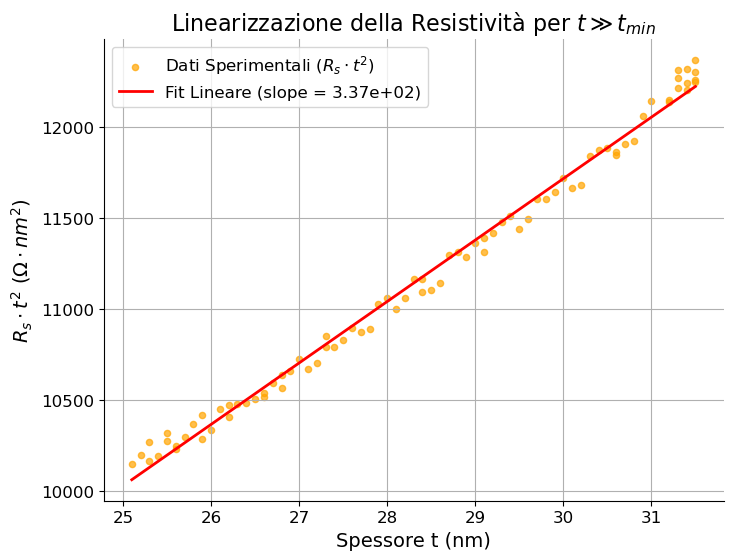

In [14]:
# Regione metallica continua: grain size
mask_inf = mask_C & (T > 25)
T_inf1 = T[mask_inf]
R_inf1 = R[mask_inf]

# R VA MOLTIPLICATO PER (LARGHEZZA DELLA MASCHERA/LUNGHEZZA DELLA MASCHERA)
W = 2
L = 5 # è solo un'ipotesi, in mm
s_factor = W / L
R_inf1 = R_inf1 * s_factor
RT2 = R_inf1 * (T_inf1**2)

def retta(x, m, q):
    return m * x + q

# fit
popt, pcov = curve_fit(retta, T_inf1, RT2)

# fit data
rho_inf = popt[0]
q = popt[1]

# errore rho_inf dal fit
errori = np.sqrt(np.diag(pcov))
err_rho_inf = errori[0] # sigma_rho_inf in Ω·nm

X2 = np.sum((rho_inf*T_inf1 + q - RT2)**2/(rho_inf*T_inf1 + q))

print(f"rho_inf = {rho_inf:.3f} ± {err_rho_inf:.1f} Ω*nm = {(rho_inf*0.001):.3f} ± {(err_rho_inf*0.001):.1f} microΩ*m")
print(f"X2 = {X2:.3}")

# Grain size
# Convertiamo in metri
rho_inf_m = rho_inf * 1e-9
err_rho_inf_m = err_rho_inf * 1e-9

# D_g
D_g_m = (rho_0 * lambda_0) / (rho_inf_m - rho_0) # m

# Propagazione dell'errore su D_g_m
err_Dg_m = (rho_0 * lambda_0 / ((rho_inf_m - rho_0)**2)) * err_rho_inf_m

# in nanometri
D_g_nm = D_g_m * 1e9 # nm
err_Dg_nm = err_Dg_m * 1e9 # nm

print(f"Grain size D_g = {D_g_nm:.2f} ± {err_Dg_nm:.2f} nm")


# plotting - rho_inf
plt.figure(figsize=(8,6))
plt.scatter(T_inf1, RT2, color='orange', label='Dati Sperimentali ($R_s \cdot t^2$)', s=20, alpha=0.7)

# Calcoliamo i punti della retta fittata
Y_fit = (rho_inf * T_inf1) + q
plt.plot(T_inf1, Y_fit, color='red', linewidth=2, label=f'Fit Lineare (slope = {rho_inf:.2e})')

plt.xlabel('Spessore t (nm)')
plt.ylabel('$R_s \cdot t^2$ ($\Omega \cdot nm^2$)')
plt.title('Linearizzazione della Resistività per $t \gg t_{min}$')
plt.legend()
plt.grid(True)
plt.savefig('fig/vetro_2_28_04/rho_inf_1.pdf', format='pdf', bbox_inches='tight')
plt.show()

### Visualizzazione rate di deposizione

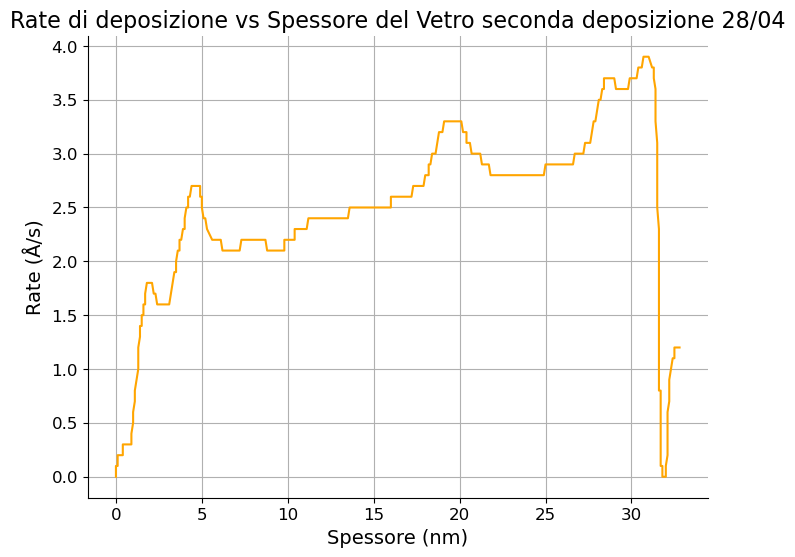

Rate medio di deposizione: 1.07 Å/s
Deviazione standard del rate: 1.26 Å/s


In [15]:
dato = np.loadtxt('data/vetro_2_28_04.txt', usecols=(4),skiprows=1)
rates2 = dato 



plt.figure(figsize=(8,6))
plt.plot(T, rates2, color='orange', linestyle='-')
plt.xlabel('Spessore (nm)')
plt.ylabel('Rate (Å/s)')
plt.title('Rate di deposizione vs Spessore del Vetro seconda deposizione 28/04')
plt.grid()
plt.show()

ratemedio2=np.mean(rates2)
print(f"Rate medio di deposizione: {ratemedio2:.2f} Å/s")
dvstd2=np.std(rates2)
print(f"Deviazione standard del rate: {dvstd2:.2f} Å/s")

# La media è sbagliata palese...

# Terza deposizione - vetro 3, 05/05

[//]: # (Nella terza deposizione cerchiamo di mantenere costante un rate di 3 Å/s)

### Identificazione regione ohmica

Minimo a T = 23.799999999999997 nm
Valore minimo R*T^2 = 10.429540352166478
Il valore esatto in cui la differenza passa per lo 0 (T_min) è: 24.235 nm


/var/folders/pv/g7twvrbn3wl5dfj28y3cp65h0000gp/T/ipykernel_2275/2137301718.py:48: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  T_zero_esatto = fsolve(f_interpolata, guess_iniziale)[0]


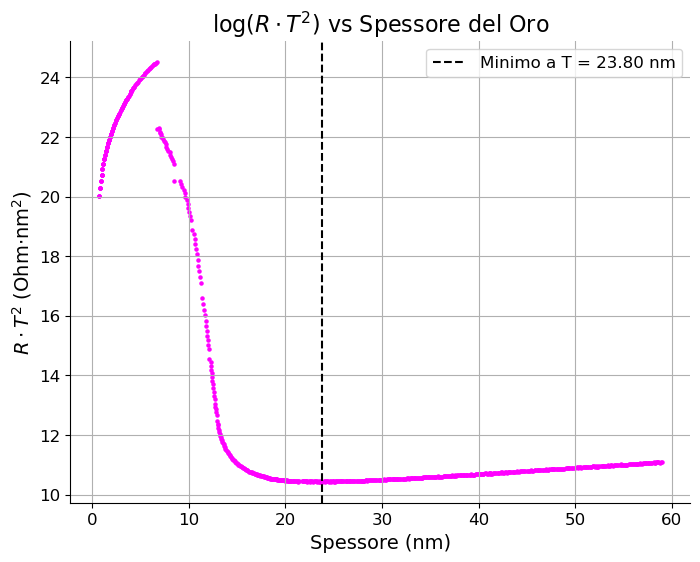

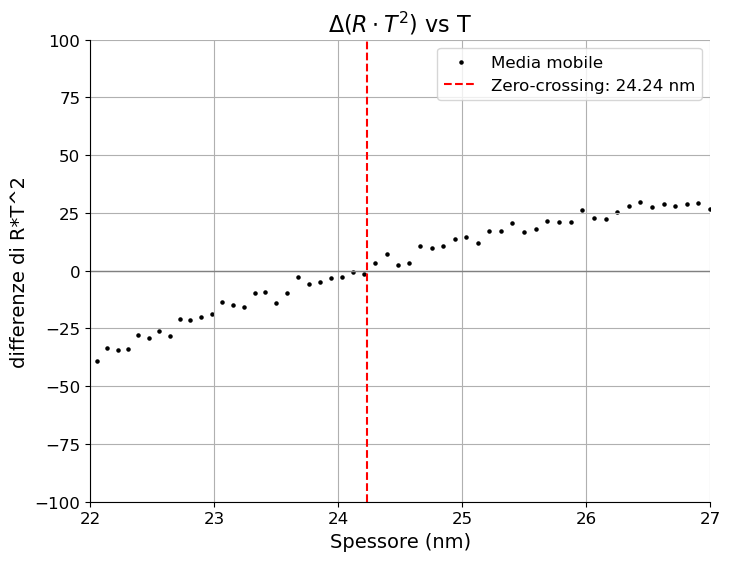

In [16]:
#TERZA DEPOSIZIONE 05/05

data = np.loadtxt('data/vetro_3_05_05.txt',usecols=(0,1),skiprows=1)
#estraiamo le colonne
R=data[:,0] #resistenza
T=data[:,1]*100 #thickness

#------------------CALCOLO RT^2 PER STIMARE REGIONE OHMICA-------------------
mask= (T > 0) & (R > 0) & (T < 60)
Tohm= T[mask]
Rohm= R[mask]
RT2 = Rohm * Tohm**2
logRT2 = np.log(RT2)
idx_min = np.argmin(RT2)
T_min3 = Tohm[idx_min]
logRT2_min = logRT2[idx_min]
print("Minimo a T =", T_min3, "nm")
print("Valore minimo R*T^2 =", logRT2_min)
plt.figure(figsize=(8,6))
plt.scatter(Tohm, logRT2, color='magenta', s=5)
plt.axvline(x=T_min3, color='black', linestyle='--', linewidth=1.5,label=fr'Minimo a T = {T_min3:.2f} nm')
#plt.xlim(15,30)
#plt.ylim(10,12)
plt.xlabel('Spessore (nm)')
plt.ylabel(r'$R \cdot T^2$ (Ohm$\cdot$nm$^2$)')
plt.title(r'log($R \cdot T^2$) vs Spessore del Oro')
plt.grid()
plt.legend()

differenzey = np.diff(RT2)
finestra=100
media_mobileRT2 = np.convolve(differenzey, np.ones(finestra)/finestra, mode='valid')
media_mobileTohm=np.convolve(Tohm[:-1], np.ones(finestra)/finestra, mode='valid')

# questi li si definisce a occhio, guardando RT^2 vs T
x_inf = 22
x_sup = 27

# Interpolazione
mask_zoom = (media_mobileTohm >= x_inf) & (media_mobileTohm <= x_sup) # limitiamoci a quello che visualizziamo
T_zoom = media_mobileTohm[mask_zoom]
Diff_zoom = media_mobileRT2[mask_zoom]

# Creiamo una funzione di interpolazione
f_interpolata = interp1d(T_zoom, Diff_zoom, kind='linear')

guess_iniziale = 25.0 
T_zero_esatto = fsolve(f_interpolata, guess_iniziale)[0]

# e quindi 
T_min3 = T_zero_esatto

print(f"Il valore esatto in cui la differenza passa per lo 0 (T_min) è: {T_zero_esatto:.3f} nm")

# --- Visualizzazione (Opzionale ma consigliata) ---
plt.figure(figsize=(8,6))
plt.scatter(media_mobileTohm, media_mobileRT2, color='black', s=5, label='Media mobile')
plt.axhline(0, color='gray', linestyle='-', linewidth=1) # Linea dello zero
plt.axvline(T_zero_esatto, color='red', linestyle='--', label=f'Zero-crossing: {T_zero_esatto:.2f} nm')

plt.xlabel('Spessore (nm)')
plt.xlim(x_inf, x_sup)
plt.ylim(-100, 100)
plt.ylabel("differenze di R*T^2")  
plt.title(r'$\Delta$($R \cdot T^2$) vs T')
plt.grid()
plt.legend()
plt.show()
#------------------------FINE CALCOLO RT^2------------------

### Identificazione regione di tunneling

/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1290: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1290: RuntimeWarning: invalid value encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1291: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1291: RuntimeWarning: invalid value encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1292: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1292: RuntimeWarning: invalid value encountered in divide
  c = dx1 / (dx2 * (dx1 +

T critico = 11.799999999999999 nm


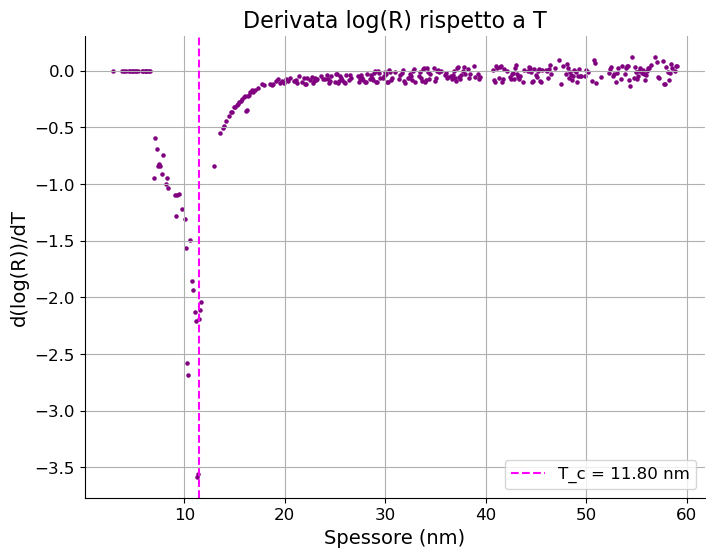

In [17]:
#------------------- FIT TUNNELING ------------------
mask = (T > 6.7) & (T < 11.5) & (R > 0)
T_tun = T[mask]
R_tun = R[mask]
# --- modello tunneling ---
# R = R0 * exp(-alpha * d)
def tunnel_model(d, R0, alpha):
    return R0 * np.exp(-alpha * d)

# --- fit in log-space ---
# log R = log R0 - alpha*d
def log_tunnel_model(d, logR0, alpha):
    return logR0 - alpha * d
p0 = [np.log(np.max(R_tun)), 1.0]
params, cov = curve_fit(
    log_tunnel_model,
    T_tun,
    np.log(R_tun),
    p0=p0,
    maxfev=10000
)
logR0_fit, alpha_fit3 = params
R0_fit3= np.exp(logR0_fit)
# --- curva fit ---
T_curvetun = np.linspace(6.7, 11.5, 500)
R_curvetun = tunnel_model(T_curvetun, R0_fit3, alpha_fit3)
#errori sui parametri di tunneling
errors = np.sqrt(np.diag(cov))
err_logR0, err_alpha3 = errors
#-------------------FINE FIT TUNNELING------------------

#------------------- CALCOLO DERIVATA logRvsT------------------
logR = np.log(R)
dlogR_dT = np.gradient(logR, T)
zona = (T > 11) & (T < 12)

idx_min = np.argmin(dlogR_dT[zona])
T_critico3 = T[zona][idx_min]

print("T critico =", T_critico3, "nm")
plt.figure(figsize=(8,6))
plt.scatter(T, dlogR_dT, color='purple',s=5)
plt.axvline(x=11.5, color='magenta', linestyle='--', linewidth=1.5,label=fr'T_c = {T_critico3:.2f} nm')
plt.xlabel('Spessore (nm)')
plt.ylabel('d(log(R))/dT')
plt.title('Derivata log(R) rispetto a T')
plt.legend()
plt.grid()
plt.show()
#------------------ FINE CALCOLO DERIVATA ------------------


### Identificazione regione percolativa

In [18]:
#------------------ FIT PERCOLAZIONE ------------------
mask = (T > 0) & (R > 0) & (T < 60)

# scelgo regione vicino alla percolazione
mask &= (T > 11.8) & (T < T_min3)
T_fit = T[mask]
R_fit = R[mask]
# --- modello logaritmico ---
# R = A * (d - dc)^(-t)
# log(R) = log(A) - t * log(d - dc)
def log_model(T, logA, dc, t):
    return logA - t * np.log(T - dc)
# --- guess iniziali ---
logA0 = np.log(1e4)
dc0 = 11
t0 = 1.3
p0 = [logA0, dc0, t0]
# --- bounds ---
bounds = (
    [-np.inf, 0, 0.1],
    [np.inf, np.min(T_fit)*0.999, 5.0]
)
# --- fit ---
params, cov = curve_fit(
    log_model,
    T_fit,
    np.log(R_fit),
    p0=p0,
    bounds=bounds,
    maxfev=20000
)
logA_fit, Tc_fit3, t_fit3 = params
A_fit3 = np.exp(logA_fit)
# --- curva fit ---
T_curve = np.linspace(Tc_fit3 + 0.01, np.max(T_fit), 1000)
R_curve = A_fit3 * (T_curve - Tc_fit3)**(-t_fit3)
# errori sui parametri di percolazione
errors = np.sqrt(np.diag(cov))
err_logA, err_Tc3, err_t3 = errors
#------------------FINE FIT PERCOLAZIONE------------------


### Plotting

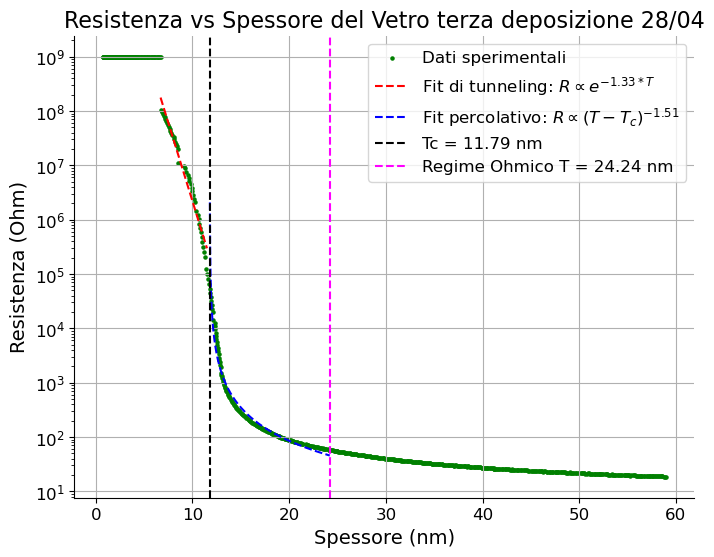

Parametri del fit di tunneling: R0*exp(-alpha*d)
R0 = 1.3216e+12 Ohm
alpha = 1.3309 1/nm ± 0.0339 1/nm
Parametri del fit percolativo: R = A * (T - Tc)^(-t)
A  = 2.0292e+03
Tc = 11.7913 nm ± 0.0143 nm
t  = 1.5059 ± 0.0247


In [19]:
#creo un grafico con dati e fit
plt.figure(figsize=(8,6))
plt.scatter(T, R, color='green', label='Dati sperimentali', s=5)
plt.plot(T_curvetun, R_curvetun, color='red', label=fr'Fit di tunneling: $R \propto e^{{{-alpha_fit3:.2f}*T}}$', linestyle='--')
plt.plot(T_curve, R_curve, color='blue',label=fr'Fit percolativo: $R \propto (T-T_c)^{{{-t_fit3:.2f}}}$',linestyle='--')

plt.axvline(x=Tc_fit3, color='black', linestyle='--', linewidth=1.5,label=fr'Tc = {Tc_fit3:.2f} nm')
plt.axvline(x=T_min3, color='magenta', linestyle='--', linewidth=1.5,label=fr'Regime Ohmico T = {T_min3:.2f} nm')
plt.yscale('log')
plt.xlabel('Spessore (nm)')

plt.ylabel('Resistenza (Ohm)')
plt.title('Resistenza vs Spessore del Vetro terza deposizione 28/04')
plt.legend()
plt.grid()
plt.show()




#------------------------ STAMPA PARAMETRI FIT ------------------
print("Parametri del fit di tunneling: R0*exp(-alpha*d)")
print(f"R0 = {R0_fit3:.4e} Ohm")
print(f"alpha = {alpha_fit3:.4f} 1/nm ± {err_alpha3:.4f} 1/nm")

print("Parametri del fit percolativo: R = A * (T - Tc)^(-t)")
print(f"A  = {A_fit3:.4e}")
print(f"Tc = {Tc_fit3:.4f} nm ± {err_Tc3:.4f} nm")
print(f"t  = {t_fit3:.4f} ± {err_t3:.4f}")

### Transizione cristallina

#### Controllo transizione di fase

In [20]:
# Transizione nanocristallino-bulk

# rho_inf
# selezione dati
data = np.loadtxt('data/vetro_3_05_05.txt',usecols=(0,1),skiprows=1)
# estraiamo le colonne
R=data[:,0] #resistenza
T=data[:,1]*100 #thickness
T_max3 = np.max(T)
mask_C = (T > T_min3) & (R>0) & (T<=T_max3)
T_ac1 = T[mask_C]
R_ac1 = R[mask_C]
RT1 = R_ac1*T_ac1
def fit_function(t, A_0, A_1, A_3):
    return A_0 + (A_1 / t) + (A_3 / (t**3))

# Bisognerebbe fare i minimi quadrati spostando man mano il punto di separazione

T_test = T_min3 # spessore test, nm
T_crit = T_min3
X2_tot = np.inf
A0_ncr = np.inf
A1_ncr = np.inf
A3_ncr = np.inf
A0_cr = np.inf
A1_cr = np.inf
A3_cr = np.inf
cov = 0

# Mo' bisognerebbe fare un bel ciclo while/for per spannare tutti i valori intorno...

dT = 0.005
while(T_test < T_max3):
    mask_ncr = mask_C & (T < T_test) # nano crystals
    mask_cr = mask_C & (T>=T_test) # crystals
    T_ncr1 = T[mask_ncr]
    T_cr1 = T[mask_cr]
    
    if len(T_ncr1) < 4 or len(T_cr1) < 4:
        T_test += dT
        continue
        
    RT_ncr1 = R[mask_ncr]*T_ncr1
    RT_cr1 = R[mask_cr]*T_cr1

    # Facciamo i due fit separatamente, vediamo per che valore di T_test c'è l'accordo migliore

    # Calcolo dei parametri:
    par_ncr1, cov_ncr1 = curve_fit(fit_function, T_ncr1, RT_ncr1)
    A0_ncr1, A1_ncr1, A3_ncr1 = par_ncr1
    par_cr1, cov_cr1 = curve_fit(fit_function, T_cr1, RT_cr1)
    A0_cr1, A1_cr1, A3_cr1 = par_cr1

    # Calcolo del X^2 = sum((x-exp)^2/exp)

    # Valori attesi con i due fit: 
    RTexp_ncr1 = fit_function(T_ncr1, A0_ncr1, A1_ncr1, A3_ncr1)
    RTexp_cr1 = fit_function(T_cr1, A0_cr1, A1_cr1, A3_cr1)

    # chi2
    X2_ncr1 = np.sum((RT_ncr1-RTexp_ncr1)**2/RTexp_ncr1)
    X2_cr1 = np.sum((RT_cr1-RTexp_cr1)**2/RTexp_cr1)
    X2_tot_new = X2_cr1 + X2_ncr1
    if(X2_tot_new < X2_tot): 
        X2_tot = X2_tot_new
        T_crit = T_test
        A0_ncr = A0_ncr1
        A1_ncr = A1_ncr1
        A3_ncr = A3_ncr1
        A0_cr = A0_cr1
        A1_cr = A1_cr1
        A3_cr = A3_cr1
        cov = cov_cr1
    T_test += dT

print(f"X^2_tot = {X2_tot:.3e}; T_crit = {T_crit:.4f}")

print(f"Fit parameters for bulk conduction (deposition 1):")
print(f"A_0 = {A0_cr:.4e} Ω·nm")
print(f"A_1 = {A1_cr:.4e} Ω·nm^2")
print(f"A_2 = {A3_cr:.4e} Ω·nm^4 \n\n")

# plottiamo 
mask_ncr_best = mask_C & (T < T_crit)
mask_cr_best = mask_C & (T >= T_crit)
T_ncr_best = T[mask_ncr_best]
T_cr_best = T[mask_cr_best]

T_ncr1_smooth = np.linspace(np.min(T_ncr_best), np.max(T_ncr_best), 200)
T_cr1_smooth = np.linspace(np.min(T_cr_best), np.max(T_cr_best), 200)

RT_ncr1_smooth = fit_function(T_ncr1_smooth, A0_ncr, A1_ncr, A3_ncr)
RT_cr1_smooth = fit_function(T_cr1_smooth, A0_cr, A1_cr, A3_cr)

plt.figure(figsize=(10, 6))

# Plot dei dati sperimentali interi
plt.scatter(T_ac1, RT1, color='orange', s=15, alpha=0.4, label='Dati Sperimentali')

# Plot del Fit 1 (nanocrystals)
plt.plot(T_ncr1_smooth, RT_ncr1_smooth, color='red', linewidth=2.5, 
         label=f'Fit Fase 1 (T < {T_crit:.2f} nm)')

# Plot del Fit 2 (bulk)
plt.plot(T_cr1_smooth, RT_cr1_smooth, color='blue', linewidth=2.5, 
         label=f'Fit Fase 2 (T > {T_crit:.2f} nm)')

# Linea verticale per indicare T_test
plt.axvline(x=T_crit, color='green', linestyle='--', linewidth=1.5, 
            label=f'Separazione ($T_{{crit}} = {T_crit:.2f}$ nm)')

plt.xlabel('Spessore $T$ (nm)', fontsize=12)
plt.ylabel('$R_s \cdot T$ ($\Omega \cdot nm$)', fontsize=12)
plt.title('Transizione Microstrutturale: Doppio Fit', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.savefig('fig/vetro_3_05_05/nanocrystalline_bulk_3.pdf', format='pdf', bbox_inches='tight')

plt.show()


KeyboardInterrupt: 

#### Grain size

rho_inf = 468.137 ± 3.3 Ω*nm = 0.468 ± 0.0 microΩ*m
X2 = 1.95e+02
Grain size D_g = 1.88 ± 0.01 nm


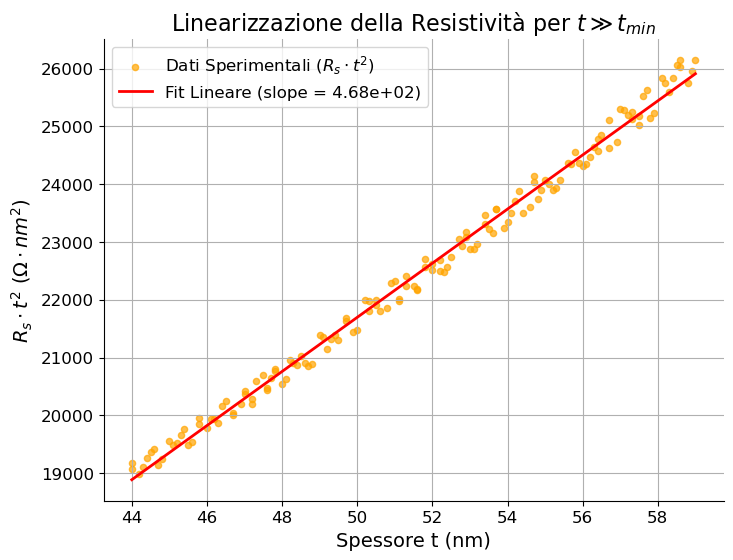

In [ ]:
# Regione metallica continua: grain size
mask_inf = mask_C & (T > T_crit)
T_inf1 = T[mask_inf]
R_inf1 = R[mask_inf]

# R VA MOLTIPLICATO PER (LARGHEZZA DELLA MASCHERA/LUNGHEZZA DELLA MASCHERA)
W = 2
L = 5 # è solo un'ipotesi, in mm
s_factor = W / L
R_inf1 = R_inf1 * s_factor
RT2 = R_inf1 * (T_inf1**2)

def retta(x, m, q):
    return m * x + q

# fit
popt, pcov = curve_fit(retta, T_inf1, RT2)

# fit data
rho_inf = popt[0]
q = popt[1]

# errore rho_inf dal fit
errori = np.sqrt(np.diag(pcov))
err_rho_inf = errori[0] # sigma_rho_inf in Ω·nm

X2 = np.sum((rho_inf*T_inf1 + q - RT2)**2/(rho_inf*T_inf1 + q))

print(f"rho_inf = {rho_inf:.3f} ± {err_rho_inf:.1f} Ω*nm = {(rho_inf*0.001):.3f} ± {(err_rho_inf*0.001):.1f} microΩ*m")
print(f"X2 = {X2:.3}")

# Grain size
# Convertiamo in metri
rho_inf_m = rho_inf * 1e-9
err_rho_inf_m = err_rho_inf * 1e-9

# D_g
D_g_m = (rho_0 * lambda_0) / (rho_inf_m - rho_0) # m

# Propagazione dell'errore su D_g_m
err_Dg_m = (rho_0 * lambda_0 / ((rho_inf_m - rho_0)**2)) * err_rho_inf_m

# in nanometri
D_g_nm = D_g_m * 1e9 # nm
err_Dg_nm = err_Dg_m * 1e9 # nm

print(f"Grain size D_g = {D_g_nm:.2f} ± {err_Dg_nm:.2f} nm")


# plotting - rho_inf
plt.figure(figsize=(8,6))
plt.scatter(T_inf1, RT2, color='orange', label='Dati Sperimentali ($R_s \cdot t^2$)', s=20, alpha=0.7)

# Calcoliamo i punti della retta fittata
Y_fit = (rho_inf * T_inf1) + q
plt.plot(T_inf1, Y_fit, color='red', linewidth=2, label=f'Fit Lineare (slope = {rho_inf:.2e})')

plt.xlabel('Spessore t (nm)')
plt.ylabel('$R_s \cdot t^2$ ($\Omega \cdot nm^2$)')
plt.title('Linearizzazione della Resistività per $t \gg t_{min}$')
plt.legend()
plt.grid(True)
plt.savefig('fig/vetro_3_05_05/rho_inf_3.pdf', format='pdf', bbox_inches='tight')
plt.show()

### Visualizzazione rate di deposizione

[//]: # (Ad ogni dato io sostituisco una media dei 5 precedenti e 5 successivi, per capire il minimo della distribuzione RT2)

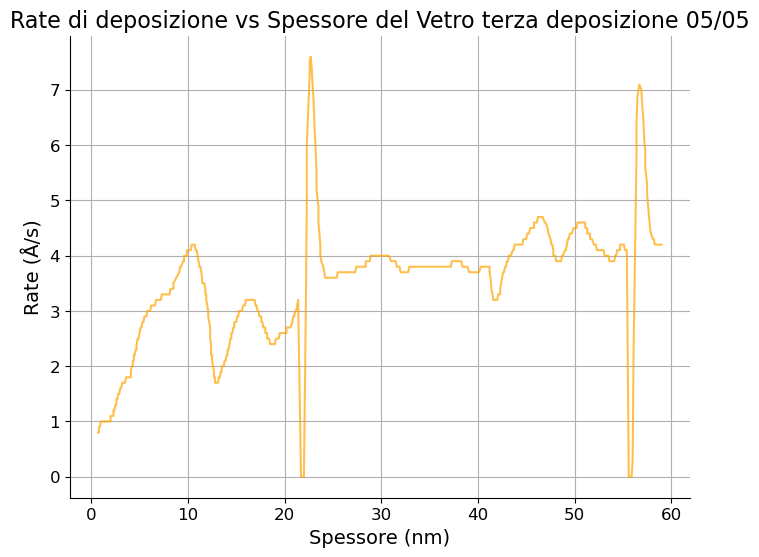

Rate medio di deposizione: 3.24 Å/s
Deviazione standard del rate: 1.26 Å/s


In [ ]:
dato = np.loadtxt('data/vetro_3_05_05.txt', usecols=(4),skiprows=1)
rates3 = dato 

plt.figure(figsize=(8,6))
plt.plot(T, rates3, color='orange', linestyle='-', alpha=0.7)
plt.xlabel('Spessore (nm)')
plt.ylabel('Rate (Å/s)')
plt.title('Rate di deposizione vs Spessore del Vetro terza deposizione 05/05')
plt.grid()
plt.show()

ratemedio3=np.mean(rates3)
print(f"Rate medio di deposizione: {ratemedio3:.2f} Å/s")
dvstd3=np.std(rates3)
print(f"Deviazione standard del rate: {dvstd3:.2f} Å/s")

## Confronto delle deposizioni

In [ ]:
#CONFRONTO TRA LE TRE DEPOSIZIONI 
#faccio una tabella in cui confronto i parametri dei tre fit di tunneling e percolazione
import pandas as pd
# creo un dizionario con i parametri
data = {
    ('Tunneling', 'R0 (Ohm)'): [R0_fit1, R0_fit2, R0_fit3],
    ('Tunneling', 'alpha (1/nm)'): [alpha_fit1, alpha_fit2, alpha_fit3],
    ('Tunneling', 'err_alpha'): [err_alpha1, err_alpha2, err_alpha3],

    ('Percolazione', 'A'): [A_fit1, A_fit2, A_fit3],
    ('Percolazione', 'Tc (nm)'): [Tc_fit1, Tc_fit2, Tc_fit3],
    ('Percolazione', 'err_Tc'): [err_Tc1, err_Tc2, err_Tc3],
    ('Percolazione', 't'): [t_fit1, t_fit2, t_fit3],
    ('Percolazione', 'err_t'): [err_t1, err_t2, err_t3],

    ('Generale', 'Rate medio (Å/s)'): [0, ratemedio2, ratemedio3]
}

index = ['Prima', 'Seconda', 'Terza']

df = pd.DataFrame(data, index=index)
pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)
print(df)

            Tunneling                        Percolazione                                                  Generale
             R0 (Ohm) alpha (1/nm) err_alpha            A    Tc (nm)    err_Tc         t     err_t Rate medio (Å/s)
Prima    9.769077e+14     3.883135  0.242330  1087.160139   5.985700  0.007270  1.304810  0.013004         0.000000
Seconda  2.274952e+13     2.629885  0.073823  1758.319694   7.248429  0.006229  1.402881  0.008649         1.069282
Terza    1.321571e+12     1.330890  0.033893  2029.210657  11.791268  0.014317  1.505895  0.024676         3.240972


## Conclusioni e domande
In effetti esattamente nello stesso punto in cui ho cambiato i due fit la derivata della resistenza in funzione dello spessore presenta una discontinuità. Evidenza del fatto che siamo in presenza di una transizione di fase.

L'unica cosa strana è il fatto che l'oro è cresciuto su vetro tendenzialmente con lo stesso rate di deposizione e in condizione ambientali analoghe in entrambe le prime due deposizioni ma le due curve percolative presentano una differenza non banale e nemmeno compatibile tra i due valori critici di spessore in cui c'è la transizione da regione di tunneling a regione di percolazione, e anche tra gli esponenti critici di entrambe le regioni...  
  
#### Cose da fare:
1. chiedere se questa cosa è plausibile, anche se è dubbio
2. cercare di capire se magari sto facendo qualcosa nell'analisi che è ricorsivo in qualche modo, perché io definisco il range delle regioni un po' a priori. nel senso che studio la derivata (graficata dopo ma logicamente la studio prima) cercando di definire il punto in cui si presenta la singolarità. che è anche il punto in cui pongo T_c.
3. ricordati comunque che per ora gli errori associati ai parametri di fit sono esclusivamente quelli statistici calcolati da curve_fit per una data regione di percolazione scelta. andranno aggiunti un po' di errori che sono sistematici di laboratorio che dobbiamo stimare.

#### Cose da implementare:   
0. Bisogna calcolare tutti gli errori, mettere le barre di errore nei grafici e aggiornare i chi quadri...
1. Posso fare dei grafici zoomabili senza dover cambiare matplotlib?
2. Posso collassare le celle di codice?  
  
### Domande
0. Come capisco la regione t >> t_min?
1. Quali sono valori accettabili di D_g?
2. Posso togliere i dati brutti alla fine?